# Automated Track Infrastructure Recognition by Using Vibration Analysis
Kooros Moabber Lule˚a University, Lule˚a, Sweden and Volvo Cars Corporation, Gothenburg, Sweden


## Introduction
Track infrastructure monitoring is critical for optimizing KPIs such as efficiency, cost, availability and safety. This monitoring is more crucial when the infrastructure is in a harsh environment and wore out due to age. Traditional maintenance is based on periodic inspections which is time consuming and costly and should be replaced with a predictive maintenance where an AI-driven approach for automated real time track monitoring is one of the best approaches. This monitoring can be done on all elements of infrastructure particularly turnouts, joins and bridges that are more vulnerable for any problem.

An approach for this monitoring is to measure the vibration detected caused by train on track by accelerometer in a specific infrastructure and combine this vibration data with GPS and expected/predefined infrastructure information to detect infrastructure elements (events) and compare their acceleration pattern with a normal pattern to detect any abnormally.

In this last report, The classification is investigated. Extract the numerical features from every vibration segment and train the classical ML models and at least one deep-learning model are implemented.

![System Setup](TrainSetup.png)
**Figure 1:** Measurement System Implementation


## Method
In the first section, labeled GPS and vibration files which includes two files are loaded.

In the second part some of selected numerical features consists of several statistical and frequency features extracted from signals, including mean, standard deviation, skewness, kurtosis, RMS and spectral characteristics (Energy, Centroid, bandwidth and flatness) are computed for every vibration segment. All data files has been concatenated in a single dataset in a proper way to save features.

In the second part, a binary classification task was performed using a Support Vector Machine (SVM) model for each element. These features were used as input variables, while the 'Bridge', 'Turnout' and 'RailJoint' columns served as the binary target labels.

The model performance was evaluated using two approaches: 
- An 80/20 train-test split
- K-fold cross-validation (with k = 5).

In the first approach, 80% of the dataset was used to train the model and the remaining 20% was used for testing. In the second approach, the dataset was divided into five folds and the model was trained and validated iteratively across different subsets to assess performance consistency and generalization capability. Accuracy, consistency of results and generalization ability have been discussed for both method. 

Another ML model which is investigated in this report is Random forest and evaluated with the same K-fold cross-validation (with k = 5).

Finally a deep learning-based classification approach is introduced to model the relationship between vibration-derived features and railway infrastructure categories (Bridge, RailJoint, and Turnout). The objective of this method is to capture complex and nonlinear patterns in the data that may not be effectively learned by classical machine learning algorithms. Two modeld are tested in this study:
- Feedforward neural network by using tesnsorflow
- Feedforward neural network by using scikit-learn

Details of these models have been explained later in this report.

## Results and Analysis
Let's start by importing the necessary packages (mostly from assignment 3):

In [1]:
import os
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import warnings
import kaleido
from IPython.display import HTML, display, Markdown
import matplotlib
import matplotlib.pyplot as plt
import plotly.express as px
from plotly.subplots import make_subplots
from pathlib import Path
import scipy.stats as stats
from scipy.stats import entropy
from scipy.fft import fft
from scipy.stats import norm
from scipy.stats import kurtosis
from scipy.stats import skew
from scipy.stats import shapiro
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import cross_validate
from sklearn.neighbors import BallTree
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.neural_network import MLPClassifier

First definition of functions to calculate of some features which are not built in is done.

In [2]:
def rms(x):
    return np.sqrt(np.mean(x**2))

def crest_factor(x):
    return np.max(np.abs(x)) / rms(x) if rms(x) != 0 else 0

def range1(x):
    return np.max(x) - np.min(x)

def dominant_freq(x, fs=1.0):
    X = np.abs(fft(x))
    freqs = np.fft.fftfreq(len(x), d=1/fs)
    return freqs[np.argmax(X[:len(X)//2])]

def spectral_energy(x):
    X = np.abs(fft(x))
    return np.sum(X**2)

def spectral_centroid(x, fs=1.0):
    X = np.abs(fft(x))[:len(x)//2]
    freqs = np.fft.fftfreq(len(x), d=1/fs)[:len(x)//2]

    if np.sum(X) == 0:
        return 0
    return np.sum(freqs * X) / np.sum(X)

def spectral_bandwidth(x, fs=1.0):
    X = np.abs(fft(x))[:len(x)//2]
    freqs = np.fft.fftfreq(len(x), d=1/fs)[:len(x)//2]

    centroid = spectral_centroid(x, fs)
    return np.sqrt(np.sum(((freqs - centroid)**2) * X) / np.sum(X))

def spectral_flatness(x):
    X = np.abs(fft(x))[:len(x)//2]
    X = X + 1e-12  # avoid log(0)

    return np.exp(np.mean(np.log(X))) / np.mean(X)

def zero_crossings(x):
    return np.sum(np.diff(np.sign(x)) != 0)

def diff_energy(v1, v2):
    return np.mean((v1 - v2)**2)

def peak_rms_ratio(x):
    return np.max(np.abs(x)) / (np.sqrt(np.mean(x**2)) + 1e-8)

def max_cross_corr(v1, v2):
    corr = np.correlate(v1 - np.mean(v1), v2 - np.mean(v2), mode="full")
    return np.max(corr) / (len(v1) + 1e-8)

def extract_extra_features(group):
    v1 = group["Vibration1"].values
    v2 = group["Vibration2"].values

    return pd.Series({
        "v12_diff_energy": np.mean((v1 - v2)**2),
        "v1_peak_rms": np.max(np.abs(v1)) / (np.sqrt(np.mean(v1**2)) + 1e-8),
        "v2_peak_rms": np.max(np.abs(v2)) / (np.sqrt(np.mean(v2**2)) + 1e-8),
    })

def extract_features(group):
    v1 = group["Vibration1"].values
    v2 = group["Vibration2"].values

    return pd.Series({
        
        "v1_dominant_freq": dominant_freq(v1),
        "v1_spectral_energy": spectral_energy(v1),
        "v1_spectral_centroid": spectral_centroid(v1),
        "v1_spectral_bandwidth": spectral_bandwidth(v1),
        "v1_spectral_flatness": spectral_flatness(v1),
        "v1_zero_crossings": zero_crossings(v1),

        "v2_dominant_freq": dominant_freq(v2),
        "v2_spectral_energy": spectral_energy(v2),
        "v2_spectral_centroid": spectral_centroid(v2),
        "v2_spectral_bandwidth": spectral_bandwidth(v2),
        "v2_spectral_flatness": spectral_flatness(v2),
        "v2_zero_crossings": zero_crossings(v2),
    })


### Data Extraction and Manipulation
Data files which are included two labeled GPS and vibration files are read as below.

In [3]:
gps = pd.read_csv("gps_kur_labeled_data_approach2.csv")
vib = pd.read_csv("vibration_kur_labeled_data_approach2.csv")
gps.info()
vib.info()
#gps.head(5)
#vib.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Latitude    78 non-null     float64
 1   timestamp   78 non-null     int64  
 2   Longitude   78 non-null     float64
 3   PointIndex  78 non-null     int64  
 4   speed       78 non-null     float64
 5   GPS_no      78 non-null     int64  
 6   file_label  78 non-null     object 
 7   Category    78 non-null     object 
 8   Bridge      78 non-null     int64  
 9   Turnout     78 non-null     int64  
 10  RailJoint   78 non-null     int64  
dtypes: float64(3), int64(6), object(2)
memory usage: 6.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77969 entries, 0 to 77968
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Vibration1  77969 non-null  float64
 1   timestamp   77969 non-null  int64  
 2   Vibration2  77969 non-nul

In this step, based on assignment 3 that showed merit of statistical features, some of them are computed here for all vibrations segments.

There are numbers of statistical and frequency features that have been extracted from primary processing of sensors data. Let's look at definition of these features:
- Statistical features:
    - Mean: The average value (sum of all numbers divided by how many numbers there are).
    - Standard Deviation (std): Tells us how much the numbers spread out from the average. Example: If most numbers are close to the mean, std is small. If they are far apart, std is big.
    - Max & Min: The biggest and smallest numbers in the dataset.
    - Range: The difference between the max and min.
    - Skewness: Tells us if the data leans more to one side (not balanced). Example: If most students score low but a few score very high, the data is skewed.
    - Kurtosis: Measures whether the data has sharp peaks or flat areas. Example: sharp peaks mean high kurtosis.
    - Root Mean Square (RMS): A special way of averaging numbers that considers both positive and negative values.
    - Crest Factor: Tells us how sharp or smooth a signal is by comparing the peak value to RMS. Example: A smooth wave has a low crest factor; a sharp peak has a high crest factor.
    - Variance: Another way to measure spread, like standard deviation, but squared. Example: If data points are close together, variance is low; if they are far apart, variance is high.
    - Zero Crossings: How many times a signal crosses the zero line. Example: A fast-changing wave crosses zero more often than a slow one.
- Frequency features:
    - Dominant Frequency: The most common frequency in the signal.
    - Spectral Energy: Tells us how much "power" is in the signal. Example: Louder sounds have more energy.
    - Spectral Centroid: Think of it like the "center of gravity" of the sound. Example: High-pitched sounds have a higher centroid than low-pitched ones, meaning their energy is concentrated more toward the higher frequencies.
    - Spectral Bandwidth: Measures how wide the range of frequencies is. Example: A single beep has low bandwidth; a mix of sounds has high bandwidth.

Statistical features in time domain are so much important for analysis therefore we start with them.
    

In [4]:
time_features = vib.groupby(["file_label", "gps_index"]).agg({
    "Vibration1": [
        "mean", "std", "max", "min",
        range1,
        skew,
        kurtosis,
        rms,
        crest_factor,
        "var"],
    "Vibration2": [
        "mean", "std", "max", "min",
        range1,
        skew,
        kurtosis,
        rms,
        crest_factor,
        "var"]
})
time_features.columns = [
    f"{col[0]}_{col[1] if isinstance(col[1], str) else col[1].__name__}"
    for col in time_features.columns
]

time_features = time_features.reset_index()


Now we calculate frequency features:

In [5]:
warnings.filterwarnings("ignore")
extra_features = vib.groupby(["file_label", "gps_index"]).apply(extract_extra_features).reset_index()
spectral_features = vib.groupby(["file_label", "gps_index"]).apply(extract_features).reset_index()
#pectral_features.info()
features = pd.merge(
    time_features,
    spectral_features,
    on=["file_label", "gps_index"],
    how="left",
    suffixes=("", "_spec")
)
features = pd.merge(
    features,
    extra_features,
    on=["file_label", "gps_index"],
    how="left"
)
#features.info()

In this step features are merged to GPS data.

In [6]:
gps_feature_total = gps.merge(
    features,
    left_on=["file_label", "PointIndex"],
    right_on=["file_label", "gps_index"],
    how="left"
)
 
#gps_feature_total.info()
gps_feature_total.head(5)

,Latitude,timestamp,Longitude,PointIndex,speed,GPS_no,file_label,Category,Bridge,Turnout,...,v1_zero_crossings,v2_dominant_freq,v2_spectral_energy,v2_spectral_centroid,v2_spectral_bandwidth,v2_spectral_flatness,v2_zero_crossings,v12_diff_energy,v1_peak_rms,v2_peak_rms
0,60.914857,206,14.816780,206,134.365500,4,file1,Turnout,0,1,...,251.0,0.103,6.493864e+06,0.111437,0.090138,0.324182,195.0,43.999335,5.531086,5.907587
1,61.003998,2711,14.580101,2711,67.488000,4,file1,Turnout,0,1,...,253.0,0.098,5.343291e+05,0.100836,0.087703,0.263797,212.0,2.962789,5.021033,7.040342
2,61.006375,2795,14.577647,2795,62.918495,4,file1,Turnout,0,1,...,331.0,0.119,5.605547e+05,0.131139,0.081508,0.317609,237.0,6.448729,4.868605,6.390110
3,61.008476,2903,14.574357,2903,42.531498,4,file1,Bridge,1,0,...,274.0,0.096,1.985722e+05,0.119190,0.087800,0.296110,206.0,0.668218,5.115537,4.815058
4,61.007133,4019,14.546763,4019,34.724503,3,file1,Turnout,0,1,...,227.0,0.105,5.203160e+05,0.106963,0.072566,0.231069,201.0,2.515704,5.752363,3.998500


In this step, data is sorted by time and normalized between 0 to 1 to avoid biasing features in models.

In [7]:
gps_feature_sorted=gps_feature_total.sort_values(by="timestamp")
#gps_final=gps_feature_sorted.drop(columns=["timestamp","gps_index"])
#gps_final=gps_feature_sorted.drop(columns=["gps_index"])
gps_final=gps_feature_sorted
exclude = ["PointIndex","file_label","Bridge","Turnout","RailJoint"]
num_cols = gps_final.select_dtypes(include=['float64','int64']).columns.difference(exclude)
gps_final[num_cols] = (gps_final[num_cols] - gps_final[num_cols].min()) / (gps_final[num_cols].max() - gps_final[num_cols].min())
gps_final.head(5)

,Latitude,timestamp,Longitude,PointIndex,speed,GPS_no,file_label,Category,Bridge,Turnout,...,v1_zero_crossings,v2_dominant_freq,v2_spectral_energy,v2_spectral_centroid,v2_spectral_bandwidth,v2_spectral_flatness,v2_zero_crossings,v12_diff_energy,v1_peak_rms,v2_peak_rms
0,0.810522,0.000000,0.338106,206,0.958602,0.2,file1,Turnout,0,1,...,0.299703,0.840708,0.264047,0.419827,0.481459,0.554301,0.502146,0.707477,0.344251,0.448479
47,0.380708,0.006319,0.633603,431,0.986965,0.4,file2,Bridge,1,0,...,0.908012,0.035505,0.110472,0.649175,0.850162,0.807670,0.652361,0.186195,0.474231,0.368539
48,0.352061,0.013734,0.659256,695,0.827818,0.4,file2,Bridge,1,0,...,0.744807,0.894771,0.171185,0.722688,0.733666,0.867293,0.630901,0.225047,0.256002,0.738005
49,0.340670,0.023142,0.674606,1030,0.055006,0.4,file2,Bridge,1,0,...,0.198813,0.159522,0.000481,0.418335,0.778992,0.818682,0.381974,0.001342,0.264182,0.203257
50,0.319148,0.056451,0.687992,2216,0.505658,0.6,file2,Turnout,0,1,...,0.326409,0.753036,0.137989,0.533797,0.411433,0.616546,0.596567,0.114819,0.391066,0.258785


Some of time features for both vibration 1 and vibration 2 has been shown in this part.

Text(0.5, 0, 'Time')

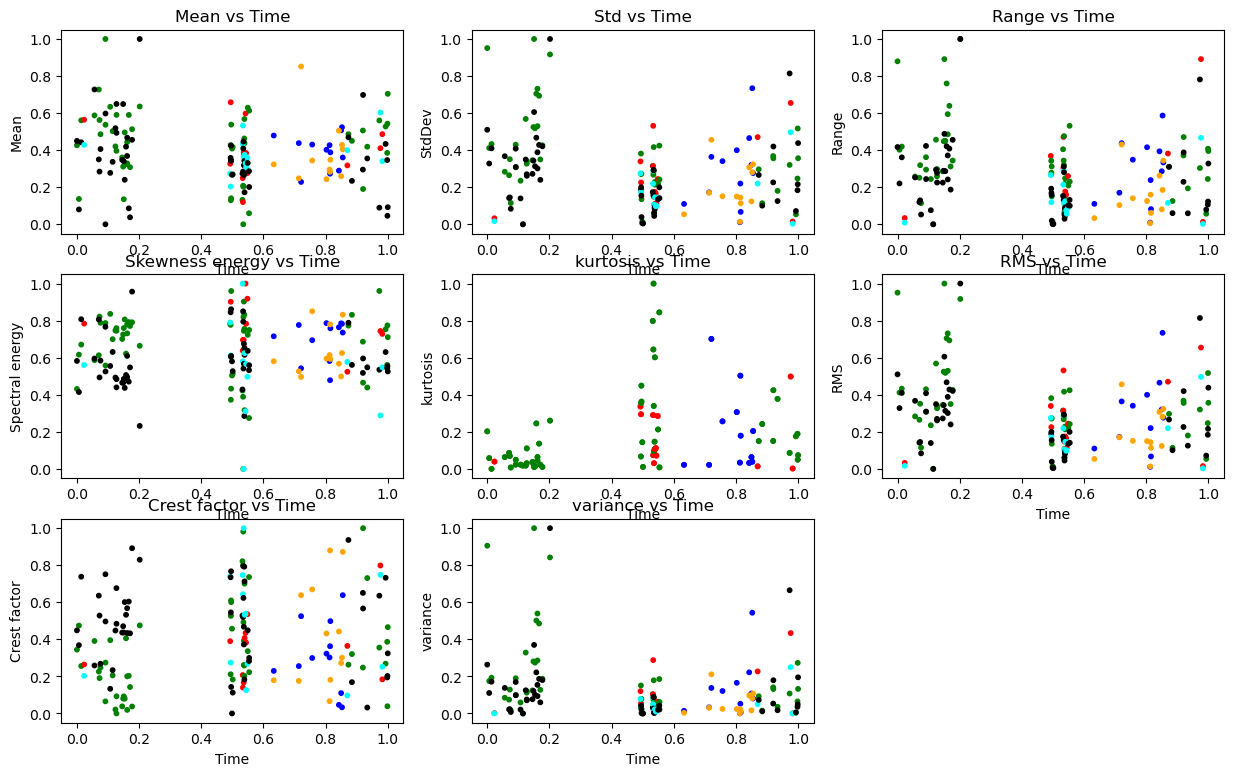

In [8]:
plt.figure(figsize=(15, 9)) # wider figures holder

#colors = gps_final['Bridge'].apply(lambda x: 'blue' if x == 0 else 'red')
colors = (
    gps_feature_total["Bridge"].map({1: "red"}).fillna("") +
    gps_feature_total["Turnout"].map({1: "green"}).fillna("") +
    gps_feature_total["RailJoint"].map({1: "blue"}).fillna("")
)

colors1 = (
    gps_feature_total["Bridge"].map({1: "cyan"}).fillna("") +
    gps_feature_total["Turnout"].map({1: "black"}).fillna("") +
    gps_feature_total["RailJoint"].map({1: "orange"}).fillna("")
)

# Replace empty with default
colors = colors.replace("", "gray")

plt.subplot(3, 3, 1)
plt.scatter(gps_final['timestamp'],gps_final['Vibration1_mean'], c=colors, s=10)
plt.scatter(gps_final['timestamp'],gps_final['Vibration2_mean'], c=colors1, s=10)
plt.title("Mean vs Time")
plt.ylabel("Mean")
plt.xlabel("Time")

plt.subplot(3, 3, 2)
plt.scatter(gps_final['timestamp'],gps_final['Vibration1_std'], c=colors, s=10)
plt.scatter(gps_final['timestamp'],gps_final['Vibration2_std'], c=colors1, s=10)
plt.title("Std vs Time")
plt.ylabel("StdDev")
plt.xlabel("Time")

plt.subplot(3, 3, 3)
plt.scatter(gps_final['timestamp'],gps_final['Vibration1_range1'], c=colors, s=10)
plt.scatter(gps_final['timestamp'],gps_final['Vibration2_range1'], c=colors1, s=10)
plt.title("Range vs Time")
plt.ylabel("Range")
plt.xlabel("Time")

plt.subplot(3, 3, 4)
plt.scatter(gps_final['timestamp'],gps_final['Vibration1_skew'], c=colors, s=10)
plt.scatter(gps_final['timestamp'],gps_final['Vibration2_skew'], c=colors1, s=10)
plt.title("Skewness energy vs Time")
plt.ylabel("Spectral energy")
plt.xlabel("Time")

plt.subplot(3, 3, 5)
plt.scatter(gps_final['timestamp'],gps_final['Vibration1_kurtosis'], c=colors, s=10)
plt.scatter(gps_final['timestamp'],gps_final['Vibration1_kurtosis'], c=colors, s=10)
plt.title("kurtosis vs Time")
plt.ylabel("kurtosis")
plt.xlabel("Time")

plt.subplot(3, 3, 6)
plt.scatter(gps_final['timestamp'],gps_final['Vibration1_rms'], c=colors, s=10)
plt.scatter(gps_final['timestamp'],gps_final['Vibration2_rms'], c=colors1, s=10)

plt.title("RMS vs Time")
plt.ylabel("RMS")
plt.xlabel("Time")

plt.subplot(3, 3, 7)
plt.scatter(gps_final['timestamp'],gps_final['Vibration1_crest_factor'], c=colors, s=10)
plt.scatter(gps_final['timestamp'],gps_final['Vibration2_crest_factor'], c=colors1, s=10)
plt.title("Crest factor vs Time")
plt.ylabel("Crest factor")
plt.xlabel("Time")

plt.subplot(3, 3, 8)
plt.scatter(gps_final['timestamp'],gps_final['Vibration1_var'], c=colors, s=10)
plt.scatter(gps_final['timestamp'],gps_final['Vibration2_var'], c=colors1, s=10)
plt.title("variance vs Time")
plt.ylabel("variance")
plt.xlabel("Time")

Pattern of train movement (sometimes trains stop) and location of elements/marker is matched with map. 
 
One interesting thing that could be find above is that different features are more suitable for detecting different elements. Bridges and rail joints by skewness and turnouts by RMS features. Crest factor can detect everything.

After time analysis, the extra columns irrelevant to ML is dropped.

In [9]:
dfsn = gps_final.drop(['Latitude','timestamp','Longitude','PointIndex','speed','GPS_no','file_label','Category'], axis=1)
print(f"Size of dataset: {dfsn.shape} ")
dfsn.columns
dfsn.head(5)

Size of dataset: (78, 39) 


,Bridge,Turnout,RailJoint,gps_index,Vibration1_mean,Vibration1_std,Vibration1_max,Vibration1_min,Vibration1_range1,Vibration1_skew,...,v1_zero_crossings,v2_dominant_freq,v2_spectral_energy,v2_spectral_centroid,v2_spectral_bandwidth,v2_spectral_flatness,v2_zero_crossings,v12_diff_energy,v1_peak_rms,v2_peak_rms
0,0,1,0,0.000000,0.426232,0.950936,0.700951,0.059961,0.879418,0.431196,...,0.299703,0.840708,0.264047,0.419827,0.481459,0.554301,0.502146,0.707477,0.344251,0.448479
47,1,0,0,0.006319,0.136596,0.411856,0.298250,0.549162,0.402162,0.616521,...,0.908012,0.035505,0.110472,0.649175,0.850162,0.807670,0.652361,0.186195,0.474231,0.368539
48,1,0,0,0.013734,0.560917,0.433104,0.391384,0.600904,0.419357,0.670781,...,0.744807,0.894771,0.171185,0.722688,0.733666,0.867293,0.630901,0.225047,0.256002,0.738005
49,1,0,0,0.023142,0.564249,0.032500,0.037369,0.971175,0.033589,0.783860,...,0.198813,0.159522,0.000481,0.418335,0.778992,0.818682,0.381974,0.001342,0.264182,0.203257
50,0,1,0,0.056451,0.587576,0.283416,0.188405,0.707675,0.257811,0.586712,...,0.326409,0.753036,0.137989,0.533797,0.411433,0.616546,0.596567,0.114819,0.391066,0.258785


### Evaluating Support Vector Machines (SVM) Performance
Evaluating the performance of a machine learning model is an essential step to ensure that the model can generalize well to unseen data. 

Since the data of category of features are one hot encoded therefore there are three binary model that should be used. 

As it is mentioned in assignment 3, there are different machine learning for binary classification such Random Forest, Gradient Boosting, K-Nearest Neighbors (KNN) and Support Vector Machine (SVM). In this report, the performance of a SVM binary classifier, when this model draws the best boundary (line or curve) to separate two groups, is assessed by using two common evaluation methods: 
- 80/20 train-test split
- K-fold cross-validation

In 80/20 train-test split, the dataset is first divided into training and testing subsets, where 80% of the data is used to train the model and the remaining 20% is used to evaluate its predictive performance.

In K-fold cross-validation dataset is randomly partitioned into k equal-sized subsets or "folds". The training and validation process is then repeated k times, where in each iteration, one specific fold is held out for validation (testing) while the remaining k-1 folds are combined to train the model. Consequently, every single data point has the opportunity to be used in the test set exactly once and in the training set k-1 times. This method is applied to provide a robust estimation of model accuracy, stability and generalization ability.

By comparing these two evaluation approaches, it is possible to analyze and compare their accuracy, consistency of results, generalization ability and the reliability of performance.

For both methods, following steps should be done:
- Selection of features (X: input) and binary target (y: output)
- Train and test data split
- Train one of the ML models (here is SVM)
- Evaluate the model by two mentioned methods for:
  - Accuracy: For measuring how much model is correct.
  - Consistency (Standard Deviation of accuracy): For measuring the consistency by 80/20 train-test split and K-fold cross-validation, you mainly look at how much the model performance varies across different runs. One method to measure consistency is to evaluate how much the model produces similar accuracy results when the data split changes. 
  - Generalization ability: This shows how well a trained model performs on new, unseen data rather than only on the data used for training. One method For measuring generalizations ability is to compare the train accuracy versus test accuracy. There are three possible scenarios when test accuracy is compared with trained accuracy:
    - Train accuracy in the same rang of test accuracy: Good generalization
    - Train accuracy >> test accuracy: Over fitting (poor generalization)
    - Train accuracy << test accuracy: Under fitting (poor generalization)

#### 80/20 Train-Test Split
In this section, the mentioned steps are followed. 
##### Selection of features and binary target:
The first step is selection of features and binary target. Binary target is 'event' field where it is either '0' for normal data and '1' if there is any event. 

In [10]:
#dfsn.columns
features =  ['Vibration1_mean','Vibration1_std', 'Vibration1_max', 'Vibration1_min', 'Vibration1_range1', 'Vibration1_skew', 
             'Vibration1_kurtosis', 'Vibration1_rms', 'Vibration1_crest_factor', 'Vibration1_var',
             'Vibration2_mean', 'Vibration2_std', 'Vibration2_max', 'Vibration2_min', 'Vibration2_range1', 'Vibration2_skew',
             'Vibration2_kurtosis','Vibration2_rms', 'Vibration2_crest_factor', 'Vibration2_var',
             'v1_dominant_freq', 'v1_spectral_energy', 'v1_spectral_centroid', 'v1_spectral_bandwidth', 'v1_spectral_flatness', 'v1_zero_crossings',
             'v2_dominant_freq', 'v2_spectral_energy', 'v2_spectral_centroid', 'v2_spectral_bandwidth', 'v2_spectral_flatness', 'v2_zero_crossings',
             'v12_diff_energy', 'v1_peak_rms', 'v2_peak_rms']  # input features
X = dfsn[features] 
y = dfsn[['Bridge', 'Turnout', 'RailJoint']].idxmax(axis=1)

##### Train and test split and train SVM binary models:
In this part the dataset is split 80% for training and 20% for testing. The model is made by train data and tested by test data. As we mentioned before in the evaluation of consistency, a single split of train and test data does not show consistency therefore we should repeat it multiple times with different random seeds. The test and train accuracies are accumulated to evaluate later.

In [11]:
test_accuracies = []
train_accuracies = []

for i in range(30):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=i, stratify=y
    )

    model = make_pipeline(
        StandardScaler(), 
        # StandardScaler()
        SVC(kernel='rbf', class_weight='balanced') 
        #SVC(kernel='rbf',C=1, gamma='scale')
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    test_acc = accuracy_score(y_test, y_pred)
    train_acc = model.score(X_train, y_train)

    test_accuracies.append(test_acc)
    train_accuracies.append(train_acc)

##### Test Accuracy, Consistency and Generalization
In this part, the accuracy mean and standard deviation show how much model is accurate and consistent. 

In [12]:
# print("Test accuracies:", np.round(test_accuracies,2))
tt_test_mean = np.round(np.mean(test_accuracies),3)
tt_test_std = np.round(np.std(test_accuracies),3)
print("80/20 Test accuracies mean:", tt_test_mean)
print("80/20 Test accuracies std:", tt_test_std )

80/20 Test accuracies mean: 0.702
80/20 Test accuracies std: 0.111


Test accuracy and standard deviation are acceptable.

For checking the generalization, the trained accuracy shows that how much the model fit to trained data. The expectation is that train accuracy mean should be higher than test accuracy mean and train accuracy stand deviation should be lower than test accuracy standard deviation since the train data are the data that is used for training model. comparison of Train accuracy and test accuracy is a good criterion for Generalization ability that has been explained before.

In [13]:
# print("Train accuracies:", np.round(train_accuracies,2))
tt_train_mean = np.round(np.mean(train_accuracies),3)
tt_train_std = np.round(np.std(train_accuracies),3)
print("80/20 Train accuracies mean:", tt_train_mean)
print("80/20 Train accuracies std:", tt_train_std)


80/20 Train accuracies mean: 0.907
80/20 Train accuracies std: 0.026


In our case train accuracy mean is higher than test accuracy mean therefore there is a over-fitting and weak generalization. The relatively low standard deviation indicates stable model behavior.

#### K-fold cross-validation
The k-fold (5-fold) cross validation is Performed on the training set to evaluate model stability. 

In [14]:
kmodel = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf', class_weight='balanced') # SVC non-linear modeling with Radial Basis Function (RBF)
    # SVC(kernel='rbf', C=1.0, gamma='scale')
)

cvn = RepeatedStratifiedKFold(n_splits=5, n_repeats=30, random_state=42)
cv_results = cross_validate(kmodel, X, y, cv=cvn, return_train_score=True)

selected_feature_kf = features
selected_features_kf_no = len(selected_feature_kf)

test_scores = cv_results['test_score']
train_scores = cv_results['train_score']

#print("Test accuracies:", np.round(test_scores,2))
kf_test_mean = np.round(test_scores.mean(),3)
kf_test_std = np.round(test_scores.std(),3)
print("K-Fold Test accuracies mean:", kf_test_mean)
print("K-Fold Test accuracies std:", kf_test_std )
#print("Train accuracies:", np.round(train_scores,2))
kf_train_mean = np.round(train_scores.mean(),3)
kf_train_std = np.round(train_scores.std(),3)
print("K-Fold Train accuracies mean:", kf_train_mean)
print("K-Fold Train accuracies std:", kf_train_std)

K-Fold Test accuracies mean: 0.726
K-Fold Test accuracies std: 0.099
K-Fold Train accuracies mean: 0.89
K-Fold Train accuracies std: 0.028


The SVM model achieved a mean test accuracy of 0.726 ± 0.099 using repeated stratified 5-fold cross-validation. The corresponding training accuracy was 0.89 ± 0.028. The gap between training and test performance suggests mild over-fitting and weak generalization again, while the relatively low standard deviation indicates stable model behavior.

The confusion matrix reveals uneven class-wise performance. The confusion matrix for these three elements is checked in this step.

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_pred = cross_val_predict(kmodel, X, y, cv=cv)

print("y: ['Bridge', 'Turnout', 'RailJoint']")
print(confusion_matrix(y, y_pred))

y: ['Bridge', 'Turnout', 'RailJoint']
[[ 8  2  3]
 [ 3  8  1]
 [ 9  3 41]]


Results:
- Bridge: 8 correct, 5 misclassified as Turnout and railjoint
- RailJoint: fairly balanced (8 correct) and 4 misclassified
- Turnout: very strong (41 correct), but absorbs errors from others

The model achieves strong classification results for the dominant class/element (Turnout), which shows high recall and absorbs a significant portion of misclassified samples from other classes. In contrast, the performance for Bridge and RailJoint is weaker and less consistent. Bridge samples are frequently misclassified as Turnout, indicating notable feature overlap between these classes. Additionally, some confusion between Bridge and RailJoint is observed, suggesting that the extracted features do not provide sufficient power to clearly separate these infrastructure types. Overall, the results highlight limited class separability in the current feature space.


### Random Forest Classification
In this step we use another ML modeling which is Random Forest classifications. This method has been explained in assignment 3. Let's test a group of parameters of this model to find the best in our problem. These parameters are used in model.

In [16]:
param_grid = {
    'max_depth': [3, 6, 8, 10],
    'min_samples_leaf': [5, 10, 15],
    'n_estimators': [200, 300, 400],
}

grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    #RandomForestClassifier(class_weight={'Bridge': 5,'RailJoint': 4,'Turnout': 1}, random_state=42),
    param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1
)

grid.fit(X, y)

print(grid.best_params_)

{'max_depth': 3, 'min_samples_leaf': 10, 'n_estimators': 300}


In [17]:
rf_model =RandomForestClassifier(
    n_estimators=300,
    max_depth=3,
    min_samples_leaf=10,
    class_weight='balanced',
    #class_weight = {'Bridge': 5,'RailJoint': 4,'Turnout': 1},
    random_state=42,
    n_jobs=-1
)

cvn = RepeatedStratifiedKFold(n_splits=5, n_repeats=30, random_state=42)

cv_results = cross_validate(
    rf_model, X, y,
    cv=cvn,
    scoring=['accuracy', 'f1_macro'],
    return_train_score=True,
    n_jobs=-1
)

test_scores = cv_results['test_accuracy']
train_scores = cv_results['train_accuracy']

rf_test_mean = test_scores.mean()
rf_test_std = test_scores.std()

rf_train_mean = train_scores.mean()
rf_train_std = train_scores.std()

rf_f1_mean = cv_results['test_f1_macro'].mean()

print(f"Test accuracy:  {rf_test_mean:.3f} ± {rf_test_std:.3f}")
print(f"Train accuracy: {rf_train_mean:.3f} ± {rf_train_std:.3f}")
print(f"F1-macro:       {rf_f1_mean:.3f}")
print(f"Min/Max test accuracy: {test_scores.min():.3f} / {test_scores.max():.3f}")

display(Markdown(
    f"**Random Forest Result:** Mean test accuracy = {rf_test_mean:.3f} ± {rf_test_std:.3f}. "
    f"Training accuracy = {rf_train_mean:.3f} ± {rf_train_std:.3f}. "
    f"Macro F1-score = {rf_f1_mean:.3f}. "
    f"The gap between training and test accuracy suggests "
    f"{'good generalization' if abs(rf_train_mean - rf_test_mean) < 0.05 else 'some degree of overfitting'}."
))

Test accuracy:  0.763 ± 0.091
Train accuracy: 0.864 ± 0.028
F1-macro:       0.638
Min/Max test accuracy: 0.533 / 0.938


**Random Forest Result:** Mean test accuracy = 0.763 ± 0.091. Training accuracy = 0.864 ± 0.028. Macro F1-score = 0.638. The gap between training and test accuracy suggests some degree of overfitting.

In this model, generalization is better than SVM but model is stable with high precision due to very small standard deviation.

In this step, the confusion matrix is checked.

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_pred = cross_val_predict(rf_model, X, y, cv=cv, n_jobs=-1)

cm = confusion_matrix(y, y_pred)

print("y: ['Bridge', 'Turnout', 'RailJoint']")
print(cm)


#ConfusionMatrixDisplay(cm).plot()
#plt.show()

y: ['Bridge', 'Turnout', 'RailJoint']
[[ 6  3  4]
 [ 1 10  1]
 [ 6  2 45]]


The model performs best on RailJoint, achieving a high number of correct classifications and strong recall. It shows that this class is well represented in the feature space. Turnout is also classified relatively good, with limited misclassification into other classes.

In contrast, Bridge is the most challenging element with a many misclassifications as both Turnout and RailJoint. This shows feature overlapping with difficulties to distinguish between Bridge and the other classes.

Additionally, some confusion is observed between RailJoint and Bridge.

Despite applying class weighting and regularization, the Random Forest model still suffers from robustly separation of all elements.

### Deep Learning
A deep learning-based classification approach is introduced to model the relationship between vibration-derived features and railway infrastructure categories (Bridge, RailJoint, and Turnout). The objective of this method is to capture complex and nonlinear patterns in the data that may not be effectively learned by classical machine learning algorithms.

General steps in deep learning which are explained later are listed here:
- pre-processing
- train/test split
- class imbalance handling
- model
- training
- evaluation
- confusion matrix

In the first step, the dataset is prepared for supervised learning (pre-processing). 

The feature matrix X contains numerical vibration-based features, while y contains the class labels (Bridge, RailJoint and Turnout). 

Although there is no non-coded value, since machine learning models require numerical inputs, the categorical labels are first converted into integer-encoded values for the future applications.

A train-test split is randomly applied (20% and 80%), ensuring that each class is proportionally represented in both training and testing sets. This is important due to the relatively small dataset size, as it helps maintain class distribution consistency between splits.

In [19]:
# help from Claude
# preprocessing
classes = np.unique(y)
print(classes)
class_to_index = {c: i for i, c in enumerate(classes)}
y_encoded = np.array([class_to_index[v] for v in y])
# print(y_encoded)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded)

['Bridge' 'RailJoint' 'Turnout']


Although normalization has been done before, the variance of the neural network should be 1 therefore this step is essential for our approach. It ensures that all features distribute and therefore contribute equally during training and prevents features with larger numeric ranges (bigger variance) from dominating the learning process.

Scaling is fitted only on the training data and then applied to training data by applying the same scaling to avoid data leakage.

In [20]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In this step, class weights assigns higher weights to underrepresented classes  and lower weights to dominant ones. This helps the model avoid bias toward the majority class.

The computed weights are sent into the training process so that minority classes is used more during optimization (it has been done for SVM and rain forest models as well).

In [21]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print("Class weights:", class_weights)

Class weights: {0: 2.066666666666667, 1: 2.066666666666667, 2: 0.49206349206349204}


Bridges and rail joints with the same number of detected events have got the same weight and turnout with many detetions have got the lowwer weight.

In this step, two model are tested:
- Feedforward neural network by using tesnsorflow: The model consists of three hidden layers with decreasing neuron sizes (128 → 64 → 32). The first layer receives input with dimensionality equal to the number of extracted features (X_train.shape[1]). The second hidden layer, introduces non-linearity and helps the model capture complex relationships in the vibration data. Batch Normalization layers are applied after the first two dense layers to stabilize learning. Dropout layers (0.3) are included to reduce over-fitting. The final output layer converts raw outputs into probability distributions across the three classes (Bridge, RailJoint, Turnout).
- Feedforward neural network by using scikit-learn: The network architecture consists of two hidden layers with 128 and 64 neurons. like previous model, the activation function used in the hidden layers is ReLU (Rectified Linear Unit). The model is trained for a maximum of 500 iterations.

In [22]:
# help from Claude

model = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(32, activation='relu'),

    layers.Dense(len(classes), activation='softmax')
])

'''model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    max_iter=500,
    random_state=42
)'''

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               4608      
                                                                 
 batch_normalization (BatchN  (None, 128)              512       
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 batch_normalization_1 (Batc  (None, 64)               256       
 hNormalization)                                                 
                                                                 
 dropout_1 (Dropout)         (None, 64)                0

The model is trained by using splitted data in the first step. The training process runs for 50 epochs with a batch size of 16 and weights we have calculated before.

In [23]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=16,
    class_weight=class_weights,
    verbose=0
)

After training, the model generates probability predictions for the test set. These test set are converted into class labels using argmax. Performance is evaluated using a classification report.

A confusion matrix is also generated again to visualize misclassification patterns between classes/elements.

In [24]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=classes))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
#disp.plot()
#plt.show()

1/1 [==============================] - 0s 140ms/step

Classification Report:

              precision    recall  f1-score   support

      Bridge       0.00      0.00      0.00         3
   RailJoint       0.50      0.50      0.50         2
     Turnout       0.77      0.91      0.83        11

    accuracy                           0.69        16
   macro avg       0.42      0.47      0.44        16
weighted avg       0.59      0.69      0.64        16

[[ 0  0  3]
 [ 1  1  0]
 [ 0  1 10]]


The classification results show uneven performance across classes. 

The model performs well on the dominant class (Turnout), achieving high recall (0.91) and a strong F1-score (0.83), indicating that most Turnout samples are correctly identified.

In contrast, the model completely fails to recognize the Bridge elements, with zero precision. The confusion matrix confirms that all Bridge samples are misclassified.

The RailJoint class shows moderate performance (F1-score = 0.50), but with very limited support (only 2 correct samples).

In this step, training and validation accuracy and loss are plotted over epochs to assess model behavior during learning.

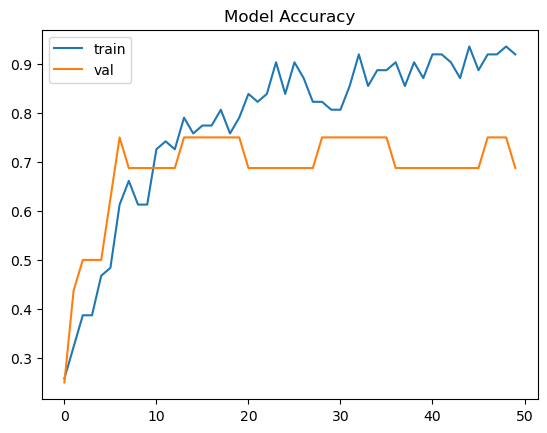

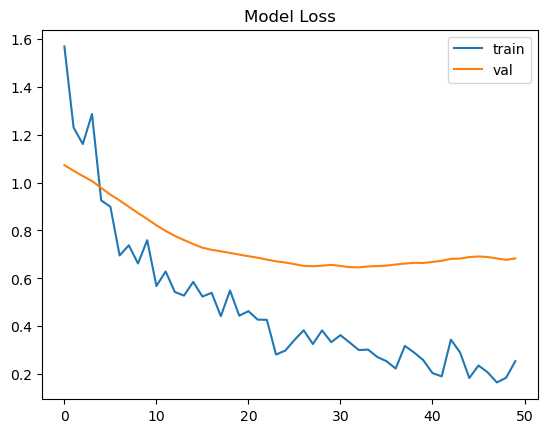

In [25]:
plt.figure()
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Model Accuracy")
plt.show()

plt.figure()
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.title("Model Loss")
plt.show()

A divergence between training and validation performance typically indicates overfitting, while stable and converging curves suggest good generalization.

Detail analysis is addressed in Discussion and summary section.

## Discussion and Summary
This study investigated the classification of railway infrastructure elements (Bridge, RailJoint and Turnout) using vibration and GPS-synchronized data. The workflow included data pre-processing, GPS-based segmentation, feature extraction from vibration signals, and supervised classification using multiple machine learning approaches.

Three classical machine learning models were evaluated: Support Vector Machine, Random Forest and Multilayer Perceptron (two methods). All models were trained on statistical and frequency-based features extracted from vibration segments aligned with GPS-defined infrastructure regions.

The Random Forest model achieved the most stable performance overall, with test accuracy around 0.75–0.76 and a macro F1-score of approximately 0.63. However a gap between training and test accuracy indicated mild over-fitting and performance varied across cross-validation folds (5 fold in k-fold cross validations). The confusion matrix showed strong classification performance for the dominant class (Turnout), while Bridge and RailJoint were slightly misclassified. it indicates class imbalance and limited feature separability.

The SVM model produced similar overall performance with a mean test accuracy of approximately 0.72. Although training performance remained high, test accuracy exhibited higher variance across folds. The model shows good performance on Turnout but has problem for distinguishing Bridge and RailJoint when there are overlapping feature distributions and sensitivity to dataset size.

The neural network achieved a moderate accuracy of about 0.69, with a macro F1-score around 0.55. Although the model captured nonlinear relationships in the data, it showed clear bias toward the dominant class. it performed weak on minority classes, particularly Bridge. This indicates that the dataset size (78 samples) is insufficient for effective deep learning generalization and limits the benefit of more complex models.

Overall, all evaluated models demonstrated a consistent pattern: good performance on the dominant class but reduced sensitivity toward minority classes. This behavior suggests that the primary limitations are not model-specific but instead arise from:
- limited dataset size
- class imbalance
- overlapping feature distributions between infrastructure types.

### Conclusion and Future Work
In conclusion, classical machine learning methods such as Random Forest and SVM provide the most reliable performance under the current dataset constraints. While neural network approaches were explored, they did not provide significant improvement due to data number limitations. 

Future improvements should focus on increasing dataset size, improving GPS–vibration synchronization accuracy, and enhancing feature engineering to improve class separability.